# Tutorial 1.1: Top-Hat Synthetic Catalogs

This notebook is a cleaner companion to Tutorial 1. It keeps the top-hat jet model, but fixes the catalogue generation logic so the number of simulated events comes from the Monte Carlo population the model sees, not from a shortcut based on the observed rate.

We cover:

1. The top-hat geometry and the role of theta_c
2. How to count the events seen by the Monte Carlo
3. How to generate GBM-like observables
4. How to generate observables with a custom sensitivity
5. How to keep E_iso and theta_c consistent in the catalogue

## Imports

In [20]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import inf
from pathlib import Path

import emcee

import notebook_setup
import src.init

from src.montecarlo import DEFAULT_LIMITS
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    create_log_probability_function,
    check_and_resume_mcmc,
    run_mcmc,
)
from src.top_hat.geometric_eff import geometric_efficiency_fixed, geometric_efficiency_flat, create_geometric_efficiency_lognormal_interpolator
from src.top_hat.plot import TopHatPlotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Why this tutorial exists

The top-hat model has a simple angular structure: a jet is bright only inside its opening angle. For a flat top-hat distribution, theta_c is drawn uniformly between 1 deg and theta_c_max. For a universal model, every jet shares the same theta_c.

For the energy column, we keep the distinction explicit:

- E_iso is the isotropic-equivalent energy inferred from the luminosity draw
- E_jet is the collimation-corrected energy, which depends on theta_c through 1 - cos(theta_c)

That dependence is the part that needs care in the non universal top-hat case.

## Setup and Priors

We keep the same flat-prior model as Tutorial 1. The only change is that the catalogue section later on uses a reusable event-count helper.

In [21]:
CUSTOM_EFFICIENCY = 0.6 # the GBM duty cycle + FOV change it to whatever you wish 

INPUT_LIMITS = DEFAULT_LIMITS.copy() # Change this to whatever you wish

## About the E_iso Calculation and GBM Efficiency

The isotropic-equivalent energy $E_{\rm iso}$ used in this notebook is computed as:

$$E_{\rm iso} = L_p \cdot T \cdot \xi$$

where:
- $L_p$ is the **peak luminosity** (in erg/s), derived from the simulated observed flux at distance
- $T$ is the **jet duration** (in seconds), here fixed to 1 s but can vary with the T90 distribution
- $\xi$ is the **peak-to-average flux ratio**, a correction factor accounting for the rise and decay of the light curve

### Derivation from Salafia et al. 2023

This follows the formalism in **Salafia et al. 2023** (A&A 680, A156), Section 4.1.1 "Jet total luminosity and energy":

The time-averaged gamma-ray luminosity is $\langle L \rangle = \xi L$, where $\xi = 0.3\, \xi_{-0.5}$ is the median peak-to-average flux ratio measured from the Fermi-GBM sample. The authors adopt a reference value of $\xi \approx 0.3$.

The conversion efficiency from bulk kinetic energy to gamma-ray emission is $\gamma = 0.1\, \gamma_{-1}$ (Beniamini et al. 2016).

Therefore, the jet core isotropic-equivalent energy is:
$$E_{c,{\rm tot,iso}} = \left(\frac{\xi}{\gamma}\right) L T \approx 9 \times 10^{51} \, \xi_{-0.5}^{-1} \gamma_{-1}^{-1} L_{51.5} T_0 \, \text{erg}$$

where $L_{51.5}$ is the peak luminosity in units of $10^{51.5}$ erg/s and $T_0$ is the duration in seconds.

This is consistent with GW170817 afterglow constraints (Ghirlanda et al. 2019) and cosmological sGRBs in general.

### Jet Energy vs Isotropic Energy

Once $E_{\rm iso}$ is computed, the collimation-corrected jet energy is obtained by dividing by the beaming correction factor:
$$E_{\rm jet} = E_{\rm iso} \cdot (1 - \cos \theta_c)$$

This accounts for the fact that a jet with half-opening angle $\theta_c$ carries less energy than the isotropic equivalent would suggest. For example, a jet with $\theta_c = 3°$ has $(1 - \cos 3°) \approx 0.0023$, so $E_{\rm jet} \ll E_{\rm iso}$.

In [22]:
datafiles   = Path('../datafiles')
output_dir  = src.init.create_run_dir('tutorial1_tophat_flat')

params = {
    "alpha"       : -0.67,
    "beta_s"      : -2.59,
    "n"           : 2,
    "z_model"     : 'fiducial_Hrad_A1.0'  # Change to 'fiducial_Hrad_TEST_A1.0' to use Tutorial 0 samples
}

default_params, _, data_dict = src.init.initialize_simulation(datafiles, params=params)

PARAM_NAMES = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'theta_c_max', 'fj']
N_PARAMS    = len(PARAM_NAMES)

k_interpolator = create_k_interpolator() # Used for top-hat k-factor

Loading existing directory  : Output_files/tutorial1_tophat_flat
Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 328, Trigger years: 17.69, Yearly rate: 18.55 events/year


## MCMC and event accounting

The MCMC setup can stay the same as Tutorial 1. The important part for this notebook is the event-count helper below: it computes how many bursts the Monte Carlo actually needs to draw before any detection cuts are applied.

In [23]:
from scipy.stats import lognorm

BURN_IN = 200

geo_interp = create_geometric_efficiency_lognormal_interpolator() # used for log-normal geometric efficiency
def expected_tophat_events(theta, params_in, n_years=4, theta_c_mode='flat'):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_value, fj = theta
    gbm_eff = CUSTOM_EFFICIENCY

    if theta_c_mode == 'flat':
        geometric_efficiency = geometric_efficiency_flat(theta_c_value)
    elif theta_c_mode == 'fixed':
        geometric_efficiency = geometric_efficiency_fixed(theta_c_value)
    elif theta_c_mode == 'log_normal':
        geometric_efficiency = geo_interp(theta_c_value)
    else:
        raise ValueError("theta_c_mode must be 'flat', 'fixed', or 'log_normal')")

    # number of years * BNS/yr * fraction within theta_c * GBM efficiency * fraction of one-sided jets
    available_events = n_years * len(params_in.z_arr) * geometric_efficiency * gbm_eff * fj
    n_events = max(1, int(np.ceil(available_events))) # make sure we have at least 1 event to simulate
    return n_events, geometric_efficiency

def draw_tophat_geometry(rng, n_events, theta_c_mode, theta_c_value, theta_c_min=1.0):
    if theta_c_mode     == 'flat':
        theta_c_deg = rng.uniform(theta_c_min, theta_c_value, size=n_events)
    elif theta_c_mode   == 'fixed':
        theta_c_deg = np.full(n_events, theta_c_value, dtype=float)
    elif theta_c_mode   == 'log_normal': # draw from a lognorm between 1 and 45 
        sigma_theta_c = 0.5 
        # Match efficiency raw calc: median = theta_c_value, sigma is in log10 space
        mu = np.log(theta_c_value)
        sigma = sigma_theta_c * np.log(10)
        
        shape = sigma
        scale = np.exp(mu)
        
        # Proper truncation using Inverse Transform Sampling
        cdf_min = lognorm.cdf(theta_c_min, s=shape, scale=scale)
        cdf_max = lognorm.cdf(45.0, s=shape, scale=scale)
        
        # Uniform samples in the valid truncated CDF range
        u = rng.uniform(cdf_min, cdf_max, size=n_events)
        
        # Map back to theta values
        theta_c_deg = lognorm.ppf(u, s=shape, scale=scale)
    else:
        raise ValueError("theta_c_mode must be 'flat', 'fixed', or 'log_normal'")

    theta_view_deg = np.degrees(np.arccos(rng.uniform(0.0, 1.0, size=n_events)))
    on_axis = theta_view_deg <= theta_c_deg
    return theta_view_deg, theta_c_deg, on_axis

def make_tophat_catalog(theta, params_in, distances, k_interpolator, 
                        n_years=4, limits=INPUT_LIMITS, theta_c_mode='flat', 
                        theta_c_min=1.0, duration_s=1.0, epsilon_factor = 0.3, seed=1234):
    
    rng = np.random.default_rng(seed)
    n_events, geo_eff = expected_tophat_events(theta, params_in, n_years=n_years, theta_c_mode=theta_c_mode)
    mc = simplified_montecarlo(theta, n_events, params_in, distances, k_interpolator, rng=rng)
    theta_view_deg, theta_c_deg, on_axis = draw_tophat_geometry(rng, n_events, theta_c_mode, theta[4], theta_c_min=theta_c_min)
    # on_axis is taken care of in simplified_montecarlo

    observed_flux   = mc['p_flux']

    trigger_mask, analysis_mask = apply_detection_cuts(
        observed_flux,
        mc['E_p_obs'],
        pflux_min=limits['F_LIM'],
        epeak_range=(limits['EP_LIM_LOWER'], limits['EP_LIM_UPPER']),
    )

    print(sum(trigger_mask))

    final_mask = analysis_mask
    if np.sum(final_mask) == 0:
        return pd.DataFrame(columns=[
            'z', 'theta_view_deg', 'theta_c_deg', 'p_flux_ph_cm2_s', 'E_p_obs_keV',
            'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg'
        ])

    e_iso_erg           = mc['L_p_obs'] * duration_s * epsilon_factor #which is the median of the peak flux to average flux ratios in the GBM sample
    e_jet_one_sided_erg = e_iso_erg * (1.0 - np.cos(np.deg2rad(theta_c_deg)))

    catalog = pd.DataFrame({
        'z': mc['z_arr'][final_mask],
        'theta_view_deg': theta_view_deg[final_mask],
        'theta_c_deg': theta_c_deg[final_mask],
        'p_flux_ph_cm2_s': observed_flux[final_mask],
        'E_p_obs_keV': mc['E_p_obs'][final_mask],
        'log_10_E_iso_erg': np.log10(e_iso_erg[final_mask]),
        'log_10_E_jet_one_sided_erg': np.log10(e_jet_one_sided_erg[final_mask]),
    })

    catalog = catalog.sort_values(['z', 'theta_view_deg']).reset_index(drop=True)
    catalog.attrs['n_events_simulated'] = n_events
    catalog.attrs['geometric_efficiency'] = geo_eff
    catalog.attrs['theta_c_mode'] = theta_c_mode
    return catalog

## Load a representative posterior sample

The catalogue examples below use the posterior median if a chain exists, otherwise they fall back to a representative parameter vector so the notebook remains usable even before the MCMC is run.

In [24]:
distances = compute_luminosity_distance(default_params.z_arr) # precompute distances for efficiency

theta_demo      = np.array([3.0, 3.0, 3.0, 0.5, 10.0, 0.5])
samples         = None
backend_path    = output_dir / 'emcee.h5'

if backend_path.exists():
    backend = emcee.backends.HDFBackend(backend_path)
    try:
        samples = backend.get_chain(discard=BURN_IN, thin=10, flat=True)
        if len(samples) > 0:
            theta_demo = np.median(samples, axis=0)
    except Exception:
        pass

print(f'Using theta_demo = {theta_demo}')
print(f'Example geometric efficiency = {expected_tophat_events(theta_demo, default_params)[1]:.4f}')

Using theta_demo = [ 4.21698615  3.03687762  3.51543663  0.44621876 11.95129976  0.40438061]
Example geometric efficiency = 0.0079


## GBM-like catalogue

This is the case you asked for first: draw the Monte Carlo population for the top-hat model, then keep only the events that survive the GBM-like cuts. The event count comes from the simulated population size, not from the observed catalogue rate.

For the flat top-hat model, theta_c is sampled event by event from 1 deg to theta_c_max.

In [25]:
N_YEARS = 10
gbm_catalog = make_tophat_catalog(
    theta=theta_demo,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    n_years=N_YEARS,
    limits=DEFAULT_LIMITS,
    theta_c_mode='flat',
    theta_c_min=1.0,
    duration_s=1.0,
    seed=42,
)

display_cols = ['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg']
print(f'GBM-like detected events: {len(gbm_catalog)}')
simulated_draws = gbm_catalog.attrs.get('n_events_simulated', 'n/a')
print(f'Simulated draws: {simulated_draws}')
gbm_catalog[display_cols].head(10)

gbm_path = output_dir / 'tophat_catalog_gbm.csv'
gbm_catalog.to_csv(gbm_path, index=False)
print(f'Saved GBM-like catalogue to {gbm_path}')

179
GBM-like detected events: 177
Simulated draws: 6876
Saved GBM-like catalogue to Output_files/tutorial1_tophat_flat/tophat_catalog_gbm.csv


## Custom sensitivity catalogue

The same helper can be reused with different detector cuts. That makes the notebook suitable for the GBM case above and for a custom sensitivity curve or a different instrument threshold.

If you are using a universal opening angle model, switch theta_c_mode to 'fixed' and pass a theta_c value instead of theta_c_max.

In [26]:
CUSTOM_LIMITS = {
    'F_LIM': 1.0,
    'EP_LIM_LOWER': 20,
    'EP_LIM_UPPER': 20_000,
}

custom_catalog = make_tophat_catalog(
    theta=theta_demo,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    n_years=10,
    limits=CUSTOM_LIMITS,
    theta_c_mode='flat',
    theta_c_min=1.0,
    duration_s=1.0,
    seed=123,
)

print(f'Custom-sensitivity detected events: {len(custom_catalog)}')
custom_catalog[['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg']].head(10)

custom_path = output_dir / 'tophat_catalog_custom_sensitivity.csv'
custom_catalog.to_csv(custom_path, index=False)
print(f'Saved custom-sensitivity catalogue to {custom_path}')

1010
Custom-sensitivity detected events: 1008
Saved custom-sensitivity catalogue to Output_files/tutorial1_tophat_flat/tophat_catalog_custom_sensitivity.csv


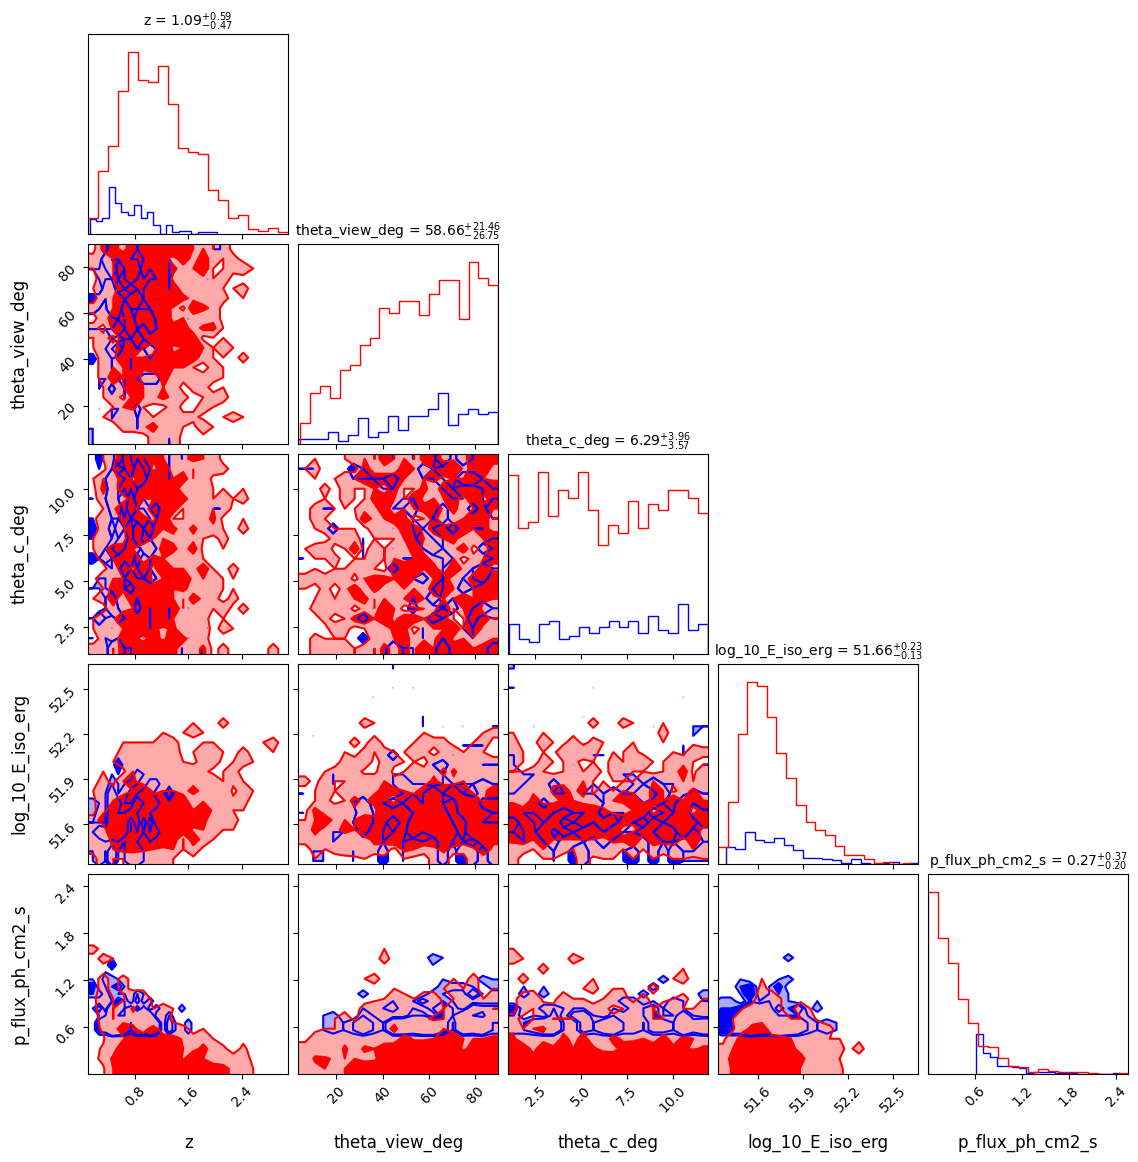

In [27]:
# corner plot comparing the two catalogs
import corner

observables = ['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'p_flux_ph_cm2_s']
gbm_samples = gbm_catalog[observables].values
custom_samples = custom_catalog[observables].values

# log10 the pflux
gbm_samples[:, -1] = np.log10(gbm_samples[:, -1])
custom_samples[:, -1] = np.log10(custom_samples[:, -1])

figure = corner.corner(
    gbm_samples,
    labels=observables,
    color='blue',
    label_kwargs={'fontsize': 12},
    show_titles=True,
    title_kwargs={'fontsize': 10},
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.68, 0.95],
    title_fmt='.2f',
)

corner.corner(
    custom_samples,
    labels=observables,
    color='red',
    label_kwargs={'fontsize': 12},
    show_titles=True,
    title_kwargs={'fontsize': 10},
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.68, 0.95],
    title_fmt='.2f',
    fig=figure,
)

plt.show()


---

## Custom Sensitivity with T90 Distribution

So far, we've assumed all events have the same duration $T = 1$ s when computing $E_{\rm iso}$. In reality, the duration of a GRB (quantified by T90, the time interval containing 90% of the counts) varies significantly across the population.

From the **Fermi-GBM catalogue**, the T90 distribution of short GRBs follows a log-normal:

$$\log_{10}(T90) \sim \mathcal{N}(\mu, \sigma)$$

with parameters:
- $\mu = 0.0208$ (in log10 scale), giving a median $T90 = 10^\mu \approx 1.05$ s
- $\sigma = 0.367$ (in dex), representing the scatter around the median

This section shows how the $E_{\rm iso}$ calculations change when we account for the realistic T90 distribution instead of assuming a constant 1 s duration for all events.

In [28]:
# Fermi-GBM T90 distribution parameters (for short GRBs)
MU_LOG10_T90 = 0.0208          # median in log10 space
SIGMA_LOG10_T90 = 0.367        # width in dex

# Quick check of the median and sigma
median_t90_s = 10**MU_LOG10_T90
print(f"T90 distribution from Fermi-GBM catalogue:")
print(f"  Median T90:      {median_t90_s:.3f} s")
print(f"  Sigma (log10):   {SIGMA_LOG10_T90}")
print(f"  Mean (log10):    {MU_LOG10_T90}")

# Generate a reference distribution
rng_ref = np.random.default_rng(42)
n_samples = 10000
log10_t90_samples = rng_ref.normal(MU_LOG10_T90, SIGMA_LOG10_T90, size=n_samples)
t90_samples = 10**log10_t90_samples

T90 distribution from Fermi-GBM catalogue:
  Median T90:      1.049 s
  Sigma (log10):   0.367
  Mean (log10):    0.0208


### Recalculating E_iso with T90 Distribution

We can take the GBM-like and custom-sensitivity catalogues already generated (which used a fixed $T=1$ s) and recompute the isotropic energies with T90 durations drawn from the Fermi-GBM distribution. This shows how the energy estimates change when we account for realistic duration variations.

In [29]:
# Re-compute E_iso for the GBM-like catalogue with T90 distribution
n_detected = len(gbm_catalog)

# Draw T90 durations for each detected event
rng_t90 = np.random.default_rng(seed=999)
log10_t90_gbm = rng_t90.normal(MU_LOG10_T90, SIGMA_LOG10_T90, size=n_detected)
t90_gbm = 10**log10_t90_gbm

# Recompute E_iso with T90-dependent durations
# E_iso_new = E_iso_old * (T90 / 1.0)  [since the original used T=1s]
E_iso_original = 10**gbm_catalog['log_10_E_iso_erg'].values  # Values from fixed T=1s
E_iso_with_t90 = E_iso_original * t90_gbm  # Scale by actual T90

# Create an augmented catalogue with T90 information
gbm_catalog_with_t90 = gbm_catalog.copy()
gbm_catalog_with_t90['T90_s'] = t90_gbm
gbm_catalog_with_t90['log_10_E_iso_erg_with_T90'] = np.log10(E_iso_with_t90)
gbm_catalog_with_t90['log_10_E_jet_one_sided_erg_with_T90'] = (
    gbm_catalog_with_t90['log_10_E_iso_erg_with_T90'] + 
    np.log10(1.0 - np.cos(np.deg2rad(gbm_catalog_with_t90['theta_c_deg'])))
)

print(f"GBM catalogue with T90 distribution:")
print(f"  Number of detected events: {len(gbm_catalog_with_t90)}")
print(f"\n  T90 statistics:")
print(f"    Mean T90:     {t90_gbm.mean():.3f} s")
print(f"    Median T90:   {np.median(t90_gbm):.3f} s")
print(f"    Std T90:      {t90_gbm.std():.3f} s")
print(f"    Range T90:    [{t90_gbm.min():.3f}, {t90_gbm.max():.3f}] s")

print(f"\n  E_iso with fixed T=1s:")
print(f"    Mean:         {10**gbm_catalog['log_10_E_iso_erg'].mean():.2e} erg")
print(f"    Median:       {10**gbm_catalog['log_10_E_iso_erg'].median():.2e} erg")

print(f"\n  E_iso with T90 distribution:")
print(f"    Mean:         {np.mean(E_iso_with_t90):.2e} erg")
print(f"    Median:       {np.median(E_iso_with_t90):.2e} erg")

# Show a few examples
display_cols_t90 = ['z', 'theta_c_deg', 'T90_s', 'log_10_E_iso_erg', 'log_10_E_iso_erg_with_T90']
print(f"\nFirst 10 events comparison (fixed T=1s vs T90):")
gbm_catalog_with_t90[display_cols_t90].head(10)

GBM catalogue with T90 distribution:
  Number of detected events: 177

  T90 statistics:
    Mean T90:     1.413 s
    Median T90:   1.144 s
    Std T90:      1.014 s
    Range T90:    [0.102, 7.210] s

  E_iso with fixed T=1s:
    Mean:         5.21e+51 erg
    Median:       4.71e+51 erg

  E_iso with T90 distribution:
    Mean:         8.77e+51 erg
    Median:       5.68e+51 erg

First 10 events comparison (fixed T=1s vs T90):


,z,theta_c_deg,T90_s,log_10_E_iso_erg,log_10_E_iso_erg_with_T90
0,0.117108,5.990332,2.003518,51.672912,51.974705
1,0.133302,7.765128,0.689502,51.676222,51.514757
2,0.155472,7.735415,0.185432,51.446667,50.714851
3,0.158095,7.304314,1.043550,51.725888,51.744401
4,0.168519,3.127013,1.637171,51.720297,51.934391
5,0.194394,6.040258,0.680134,51.458375,51.290970
6,0.197164,4.329444,0.818373,51.545086,51.458037
7,0.203132,8.605287,0.582403,51.523455,51.288679
8,0.209525,1.808532,1.556842,51.486025,51.678270
9,0.210312,9.546776,0.398345,51.595818,51.196078


In [30]:
# Save the catalogue with T90 information
gbm_t90_path = output_dir / 'tophat_catalog_gbm_with_t90.csv'
gbm_catalog_with_t90.to_csv(gbm_t90_path, index=False)
print(f"Saved GBM catalogue with T90 to {gbm_t90_path}")

Saved GBM catalogue with T90 to Output_files/tutorial1_tophat_flat/tophat_catalog_gbm_with_t90.csv


### T90 Treatment for Custom Sensitivity Catalogue

We can apply the same T90 resampling to the custom-sensitivity catalogue to show how the energy estimates change across different detection thresholds.

In [31]:
# Apply T90 distribution to the custom-sensitivity catalogue as well
n_custom = len(custom_catalog)
rng_t90_custom = np.random.default_rng(seed=888)
log10_t90_custom = rng_t90_custom.normal(MU_LOG10_T90, SIGMA_LOG10_T90, size=n_custom)
t90_custom = 10**log10_t90_custom

# Recompute E_iso with T90
E_iso_original_custom = 10**custom_catalog['log_10_E_iso_erg'].values
E_iso_with_t90_custom = E_iso_original_custom * t90_custom

# Augmented custom catalogue
custom_catalog_with_t90 = custom_catalog.copy()
custom_catalog_with_t90['T90_s'] = t90_custom
custom_catalog_with_t90['log_10_E_iso_erg_with_T90'] = np.log10(E_iso_with_t90_custom)

print(f"Custom-sensitivity catalogue with T90 distribution:")
print(f"  Number of detected events: {len(custom_catalog_with_t90)}")
print(f"\n  E_iso with fixed T=1s:")
print(f"    Mean:   {10**custom_catalog['log_10_E_iso_erg'].mean():.2e} erg")
print(f"    Median: {10**custom_catalog['log_10_E_iso_erg'].median():.2e} erg")
print(f"\n  E_iso with T90 distribution:")
print(f"    Mean:   {np.mean(E_iso_with_t90_custom):.2e} erg")
print(f"    Median: {np.median(E_iso_with_t90_custom):.2e} erg")

# Save the custom catalogue with T90
custom_t90_path = output_dir / 'tophat_catalog_custom_sensitivity_with_t90.csv'
custom_catalog_with_t90.to_csv(custom_t90_path, index=False)
print(f"\nSaved custom-sensitivity catalogue with T90 to {custom_t90_path}")

Custom-sensitivity catalogue with T90 distribution:
  Number of detected events: 1008

  E_iso with fixed T=1s:
    Mean:   4.98e+51 erg
    Median: 4.53e+51 erg

  E_iso with T90 distribution:
    Mean:   8.88e+51 erg
    Median: 5.54e+51 erg

Saved custom-sensitivity catalogue with T90 to Output_files/tutorial1_tophat_flat/tophat_catalog_custom_sensitivity_with_t90.csv


## Bonus: Duration-Dependent Sensitivity

Now that we have a realistic T90 duration distribution, we can model detection more accurately by applying a duration-dependent peak flux limit. Instruments typically have flux sensitivity thresholds that scale with integration time.

In the example below, we adapt the detection loop to apply a dynamic threshold `limit_ph` based on the T90 of each event, rather than the constant `F_LIM` threshold used previously. 

<div class="alert alert-block alert-warning">
⚠️ The "duration" of the GRBs really depends on your model assumptions. Often the exposure time is smaller than the actual T90, for example in GBM it is a fixed 64ms for the most common trigger timescale. So take the following with a grain of salt.   

Stick with the GBM sensitivity if you want more consisteny predictions (ie. look at the predicted rate below)
</div>

*(Note: For more advanced details check out [tutorial2_structured_jet.ipynb](tutorial2_structured_jet.ipynb))*

In [32]:
def peak_flux_lim(time_array, slope=-0.5, intercept=-0.50):
    """Returns the peak flux limit in ph/cm^2/s given a duration array in seconds."""
    # Some next-gen GRB detector
    return 10**(intercept) * time_array**(slope)

def make_tophat_catalog_duration_dependent(theta, params_in, distances, k_interpolator, 
                                           n_years=4, limits=INPUT_LIMITS, theta_c_mode='flat', 
                                           theta_c_min=1.0, epsilon_factor=0.3, seed=1234):
    
    rng = np.random.default_rng(seed)
    n_events, geo_eff = expected_tophat_events(theta, params_in, n_years=n_years, theta_c_mode=theta_c_mode)
    mc = simplified_montecarlo(theta, n_events, params_in, distances, k_interpolator, rng=rng)
    theta_view_deg, theta_c_deg, on_axis = draw_tophat_geometry(rng, n_events, theta_c_mode, theta[4], theta_c_min=theta_c_min)
    
    observed_flux = mc['p_flux']
    ep_obs = mc['E_p_obs']
    
    # 1. Draw T90 durations for all simulated events before cuts
    log10_t90 = rng.normal(MU_LOG10_T90, SIGMA_LOG10_T90, size=n_events)
    t90_array = 10**log10_t90
    
    # 2. Compute dynamic peak flux limit per event based on duration
    flux_thresholds = peak_flux_lim(t90_array)
    
    # 3. Apply custom duration-dependent detection cuts
    flux_mask = (observed_flux > flux_thresholds)
    ep_mask = (ep_obs > limits['EP_LIM_LOWER']) & (ep_obs < limits['EP_LIM_UPPER'])
    
    final_mask = flux_mask & ep_mask

    if np.sum(final_mask) == 0:
        return None

    e_iso_erg = mc['L_p_obs'] * t90_array * epsilon_factor
    e_jet_one_sided_erg = e_iso_erg * (1.0 - np.cos(np.deg2rad(theta_c_deg)))

    catalog_dyn = pd.DataFrame({
        'z': mc['z_arr'][final_mask],
        'theta_view_deg': theta_view_deg[final_mask],
        'theta_c_deg': theta_c_deg[final_mask],
        'p_flux_ph_cm2_s': observed_flux[final_mask],
        'flux_threshold': flux_thresholds[final_mask],
        'E_p_obs_keV': ep_obs[final_mask],
        'T90_s': t90_array[final_mask],
        'log_10_E_iso_erg': np.log10(e_iso_erg[final_mask]),
        'log_10_E_jet_one_sided_erg': np.log10(e_jet_one_sided_erg[final_mask]),
    })

    catalog_dyn = catalog_dyn.sort_values(['z', 'theta_view_deg']).reset_index(drop=True)
    return catalog_dyn

# Generate catalogue with dynamic threshold
dyn_catalog = make_tophat_catalog_duration_dependent(
    theta=theta_demo,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    n_years=N_YEARS,
    limits=CUSTOM_LIMITS,
    theta_c_mode='flat',
    seed=101
)

yearly_rate = len(dyn_catalog) / N_YEARS
print(f"Events detected with duration-dependent sensitivity: {len(dyn_catalog)}")
print(f"Yearly rate: {yearly_rate:.2f}")
display_cols_dyn = ['z', 'T90_s', 'flux_threshold', 'p_flux_ph_cm2_s', 'log_10_E_iso_erg']
display(dyn_catalog[display_cols_dyn].head(10))

Events detected with duration-dependent sensitivity: 2869
Yearly rate: 286.90


,z,T90_s,flux_threshold,p_flux_ph_cm2_s,log_10_E_iso_erg
0,0.106127,1.170328,0.292312,78.782096,52.092383
1,0.134334,7.502240,0.115453,33.037409,52.435776
2,0.165680,1.177974,0.291362,11.480806,51.633911
3,0.167755,1.170612,0.292276,43.980110,51.541096
4,0.181898,0.613815,0.403628,4.698717,51.241767
5,0.188199,1.032929,0.311146,14.882386,51.626955
6,0.209433,1.342947,0.272879,24.681849,51.640952
7,0.212552,0.197499,0.711570,3.521044,50.744191
8,0.226904,0.775208,0.359162,3.774818,51.446007
9,0.234873,0.531201,0.433881,91.812144,51.741699
